In [1]:
from sklearn import tree
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

In [31]:
!uv pip list

Package                   Version
------------------------- -----------
anyio                     4.5.2
argon2-cffi               25.1.0
argon2-cffi-bindings      21.2.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.0.4
attrs                     25.3.0
babel                     2.18.0
backcall                  0.2.0
backports-zoneinfo        0.2.1
beautifulsoup4            4.14.3
bleach                    6.1.0
certifi                   2026.4.22
cffi                      1.17.1
charset-normalizer        3.4.7
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.1.1
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
exceptiongroup            1.3.1
executing                 2.2.1
fastjsonschema            2.21.2
fonttools                 4.57.0
fqdn                      1.5.1
graphviz                  0.20.3
h11              

Using Python 3.8.20 environment at: D:\envs\scikit_learn


In [32]:
!uv pip show graphviz

Name: graphviz
Version: 0.20.3
Location: D:\envs\scikit_learn\Lib\site-packages
Requires:
Required-by:


Using Python 3.8.20 environment at: D:\envs\scikit_learn


## 导入数据集 查看基本信息

In [3]:
wine = load_wine()
wine

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [4]:
wine.data

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]])

In [5]:
wine.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [12]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [6]:
wine.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

这个数据集是一个三分类的，目标有012三个

In [7]:
import pandas as pd

In [11]:
# 用 concat 把数据中和标签连接成一个dataframe
df = pd.concat([pd.DataFrame(wine.data), pd.DataFrame(wine.target)], axis=1)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,0
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 划分训练集和测试集

In [13]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(wine.data, wine.target, test_size=0.3)

In [14]:
print(Xtrain.shape, Xtest.shape)

(124, 13) (54, 13)


## 训练决策树

In [45]:
clf = tree.DecisionTreeClassifier(criterion="entropy", random_state=42)
clf.fit(Xtrain, Ytrain)
clf.score(Xtest, Ytest)
# 可以发现每次运行的结果不同，可以指定

0.9444444444444444

## 导出绘图

In [33]:
import graphviz


(process:3028): Pango-WARNING **: 12:34:10.376: couldn't load font "霞鹜文楷 Not-Rotated 14", falling back to "Sans Not-Rotated 14", expect ugly output.


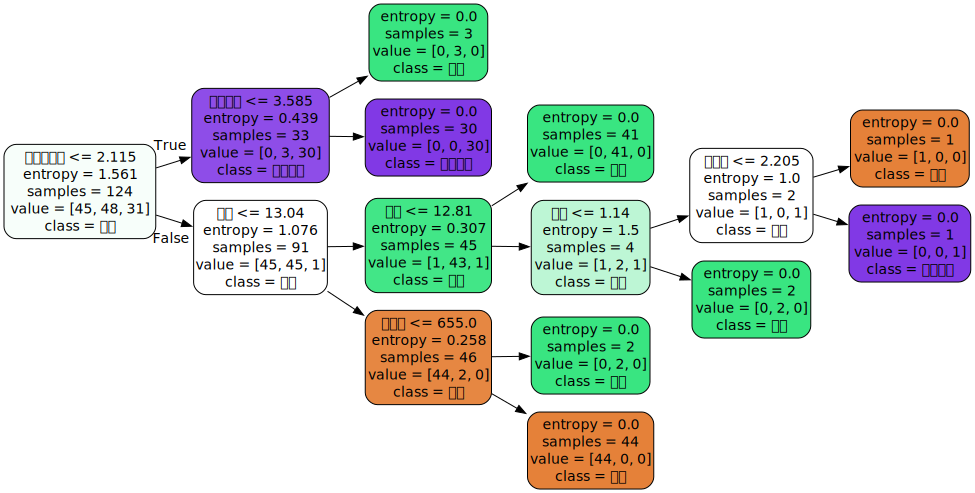

In [38]:
feature_name = ['酒精','苹果酸','灰','灰的碱性','镁','总酚','类黄酮','非黄烷类酚类','花青素','颜色强度','色调','稀释葡萄酒','脯氨酸']

dot_data = tree.export_graphviz(clf, 
                                feature_names=feature_name,
                                class_names=["琴酒", "雪莉", "贝尔摩德"],
                                filled=True,
                                rounded=True,
                                rotate=True,
                                fontname="霞鹜文楷"
                                )

graph = graphviz.Source(dot_data)
graph

最后的叶子节点不纯度为0，表示可以选取具体的类别

- filled表示是否给节点上色，越靠近叶节点的颜色越深，不纯度**越低**。
- rounded 表示边框是否有圆角

查看各个特征的重要程度：

In [39]:
clf.feature_importances_

array([0.41375614, 0.01033439, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.07494187,
       0.02066877, 0.41897014, 0.06132869])

In [43]:
# 这里可以zip一下
sorted(zip(feature_name, clf.feature_importances_), key=lambda x: x[1], reverse=True)

[('稀释葡萄酒', 0.41897014219437223),
 ('酒精', 0.4137561420003343),
 ('颜色强度', 0.07494187169283383),
 ('脯氨酸', 0.061328685367992894),
 ('色调', 0.020668772496311178),
 ('苹果酸', 0.010334386248155589),
 ('灰', 0.0),
 ('灰的碱性', 0.0),
 ('镁', 0.0),
 ('总酚', 0.0),
 ('类黄酮', 0.0),
 ('非黄烷类酚类', 0.0),
 ('花青素', 0.0)]

In [89]:
clf_random = tree.DecisionTreeClassifier(
    criterion="entropy", 
    splitter="random", 
    random_state=30,
    max_depth=3,
    min_samples_leaf=3,
    min_samples_split=13
    )

clf_random.fit(Xtrain, Ytrain)

clf_random.score(Xtest, Ytest)

0.7592592592592593


(process:13116): Pango-WARNING **: 16:25:28.838: couldn't load font "霞鹜文楷 Not-Rotated 14", falling back to "Sans Not-Rotated 14", expect ugly output.


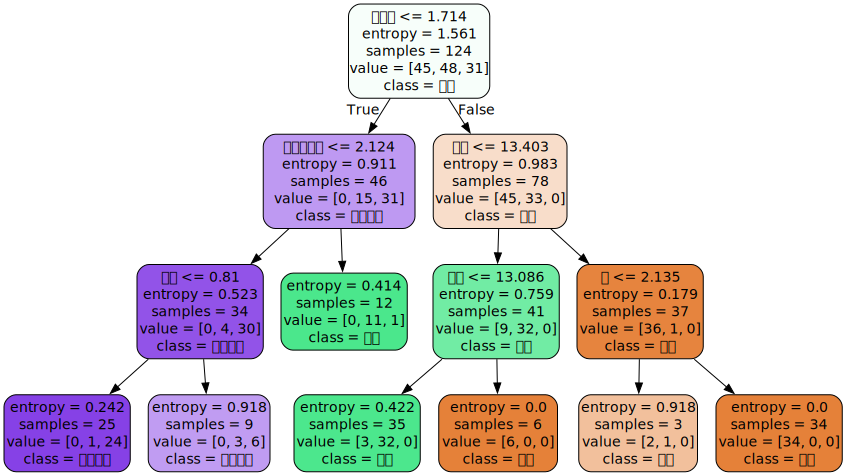

In [90]:
dot_data_random = tree.export_graphviz(clf_random, 
                                feature_names=feature_name,
                                class_names=["琴酒", "雪莉", "贝尔摩德"],
                                filled=True,
                                rounded=True,
                                # rotate=True,
                                fontname="霞鹜文楷",
                                )

graph_random = graphviz.Source(dot_data_random)
graph_random

## 超参数曲线

In [91]:
from matplotlib import pyplot as plt

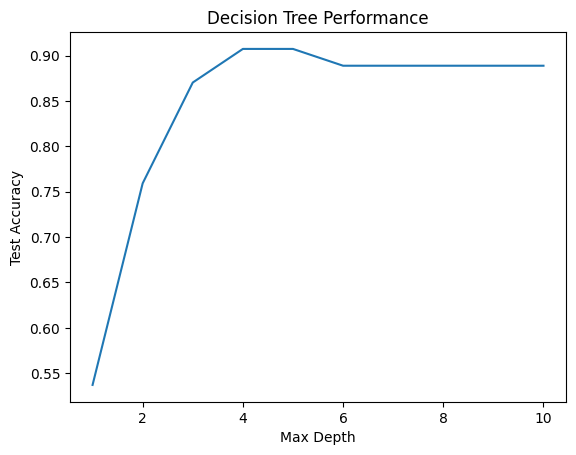

In [97]:
test = []

for i in range(10):
    clf = tree.DecisionTreeClassifier(max_depth=i+1, random_state=42, splitter="random", criterion="entropy")
    clf.fit(Xtrain, Ytrain)
    score = clf.score(Xtest, Ytest)
    test.append(score)
    
plt.plot(range(1,11), test)
plt.xlabel("Max Depth")
plt.ylabel("Test Accuracy")
plt.title("Decision Tree Performance")
plt.show()

In [ ]:
# 这里的 max_depth 为 10
clf.apply(Xtest)

array([ 3, 20,  3,  2,  2, 20,  3,  3,  3,  7, 20,  3,  7,  7,  3,  7, 20,
       20, 10,  7,  7,  7,  3,  3, 16,  3, 16,  3, 10,  3, 16,  3,  7, 20,
       16,  7, 16,  7,  7,  7,  3,  3,  7, 20,  7, 16,  7,  7,  3, 20, 20,
       20,  3, 16], dtype=int64)

In [99]:
clf.predict(Xtest)

array([2, 0, 2, 1, 1, 0, 2, 2, 2, 1, 0, 2, 1, 1, 2, 1, 0, 0, 1, 1, 1, 1,
       2, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 0, 0, 1, 0, 1, 1, 1, 2, 2, 1, 0,
       1, 0, 1, 1, 2, 0, 0, 0, 2, 0])